In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer




In [2]:
file_path = '..\\Data\\taxi_trip_pricing.csv'

dataset_df = pd.read_csv(file_path)
dataset_df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [3]:
dataset_df = dataset_df.dropna(subset=['Trip_Price']).copy()
dataset_df.shape

(951, 11)

Rows with missing Trip_Price were removed because this is the target variable for regression. 
Imputing target values would introduce artificial information and reduce model accuracy.
Only 4.9% of rows were removed (49 rows total), which is small enough to avoid negatively impacting the dataset.


In [4]:
X = dataset_df.copy().drop('Trip_Price', axis=1)
y = dataset_df['Trip_Price']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

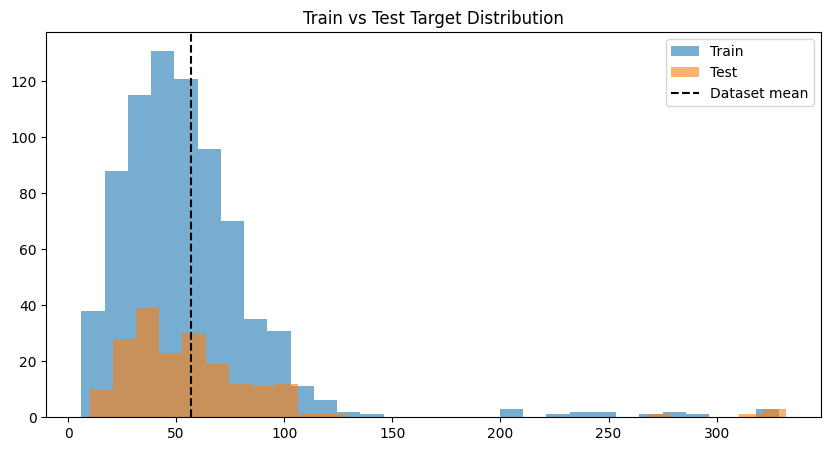

---- Target Distribution Check ----
Dataset mean/std: 56.87 / 40.47
Train mean/std:   56.03 / 38.19
Test mean/std:    60.23 / 48.47


In [26]:
# Target distribution comparison
plt.figure(figsize=(10,5))
plt.hist(y_train, bins=30, alpha=0.6, label='Train')
plt.hist(y_test, bins=30, alpha=0.6, label='Test')
plt.axvline(y.mean(), color='black', linestyle='--', label='Dataset mean')
plt.legend()
plt.title("Train vs Test Target Distribution")
plt.show()

print("---- Target Distribution Check ----")
print(f"Dataset mean/std: {y.mean():.2f} / {y.std():.2f}")
print(f"Train mean/std:   {y_train.mean():.2f} / {y_train.std():.2f}")
print(f"Test mean/std:    {y_test.mean():.2f} / {y_test.std():.2f}")

A random 80/20 split was used. The training and test sets show similar means and standard deviations relative to the full dataset, indicating a representative split. Minor differences are consistent with expected sampling variation.

# Training EDA

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760 entries, 183 to 913
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       720 non-null    float64
 1   Time_of_Day            719 non-null    object 
 2   Day_of_Week            727 non-null    object 
 3   Passenger_Count        724 non-null    float64
 4   Traffic_Conditions     717 non-null    object 
 5   Weather                722 non-null    object 
 6   Base_Fare              726 non-null    float64
 7   Per_Km_Rate            727 non-null    float64
 8   Per_Minute_Rate        720 non-null    float64
 9   Trip_Duration_Minutes  723 non-null    float64
dtypes: float64(6), object(4)
memory usage: 65.3+ KB


In [27]:
display(dataset_df.describe().T)

X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Trip_Distance_km,901.0,27.190998,20.155134,1.2300,12.63000,25.8700,38.68000,146.067047
Passenger_Count,903.0,2.479513,1.100983,1.0000,2.00000,2.0000,3.00000,4.000000
Base_Fare,907.0,3.497100,0.866729,2.0100,2.73000,3.5100,4.23000,5.000000
Per_Km_Rate,907.0,1.229934,0.429958,0.5000,0.85000,1.2200,1.61000,2.000000
Per_Minute_Rate,902.0,0.293902,0.115404,0.1000,0.19000,0.2900,0.39000,0.500000
Trip_Duration_Minutes,905.0,62.044144,32.321578,5.0100,35.59000,61.5700,89.21000,119.840000
Trip_Price,951.0,56.874773,40.469791,6.1269,33.74265,50.0745,69.09935,332.043689


,count,mean,std,min,25%,50%,75%,max
Trip_Distance_km,717.0,26.784392,19.431155,1.25,12.630,25.42,38.360,139.476515
Passenger_Count,722.0,2.454294,1.105397,1.00,1.000,2.00,3.000,4.000000
Base_Fare,727.0,3.491994,0.872147,2.02,2.725,3.51,4.250,5.000000
Per_Km_Rate,723.0,1.223845,0.424401,0.50,0.850,1.21,1.580,2.000000
Per_Minute_Rate,721.0,0.294591,0.114413,0.10,0.190,0.29,0.390,0.500000
Trip_Duration_Minutes,731.0,61.900670,32.715146,5.01,34.840,61.64,89.605,119.820000


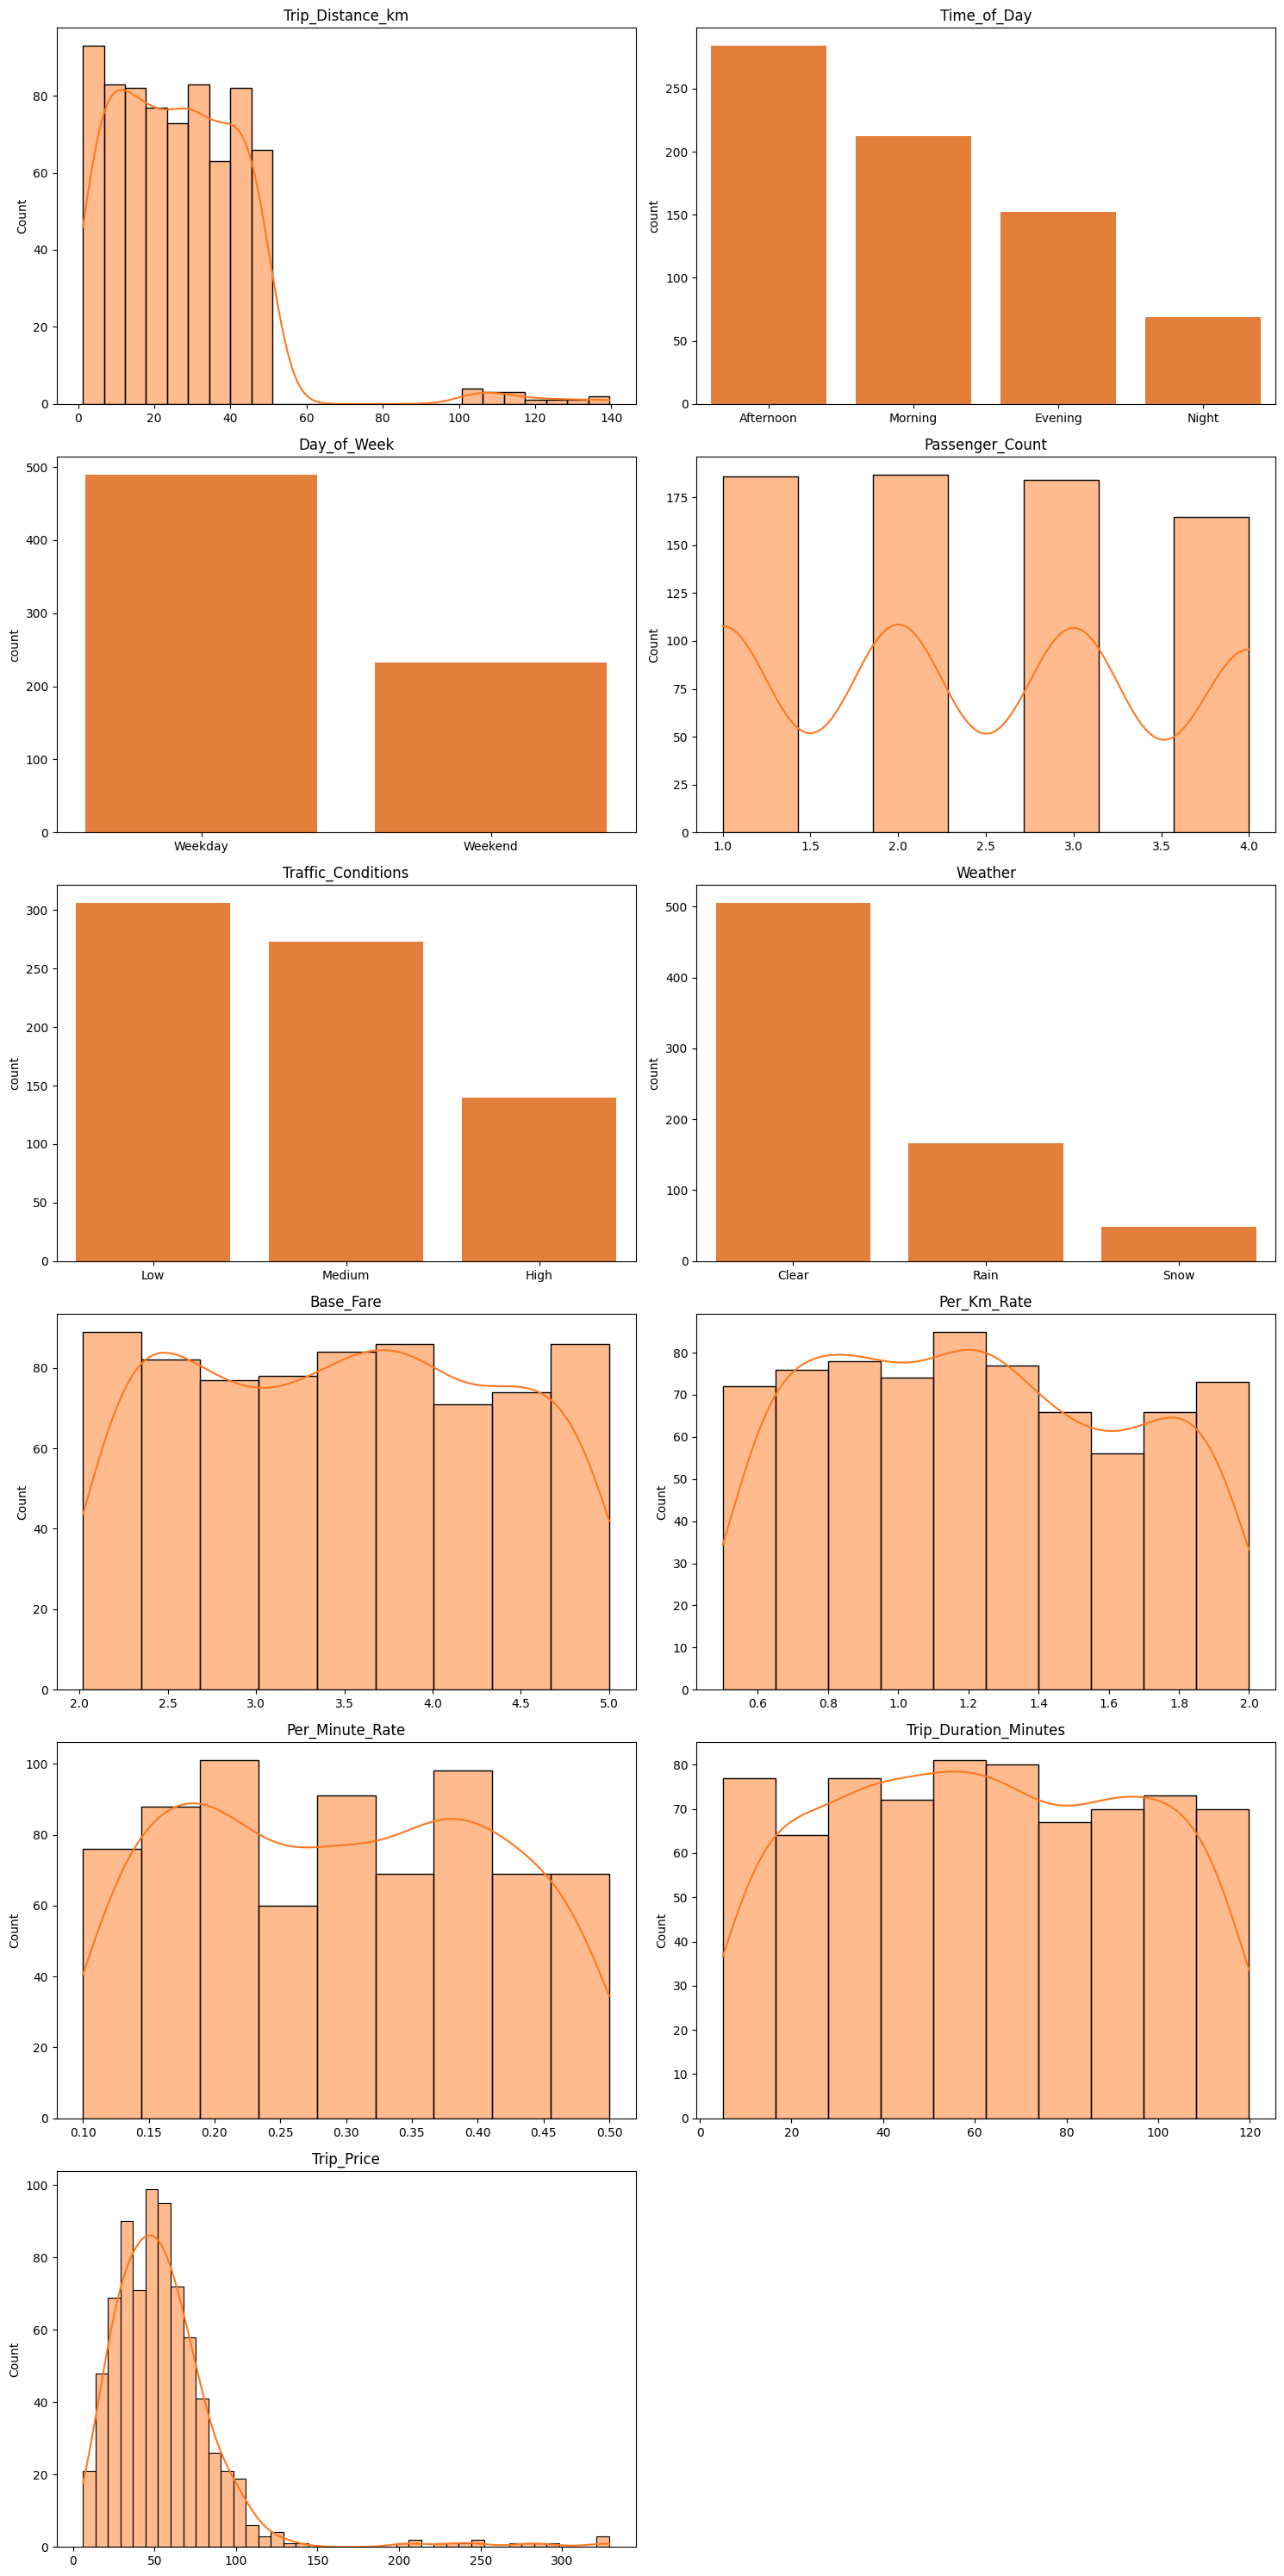

In [28]:
temp_eda_df = pd.concat([X_train, y_train], axis=1)

colors = ['#FF781F']

n_cols = 2
n_features = len(temp_eda_df.columns)
n_rows = math.ceil(n_features / n_cols)

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5*n_rows))
ax = ax.flatten()

for i, col_name in enumerate(temp_eda_df.columns):

    if not pd.api.types.is_numeric_dtype(temp_eda_df[col_name]):

        counts = temp_eda_df[col_name].value_counts().reset_index()
        # counts.columns = [col_name, 'count']

        sns.barplot(
            data=counts,
            x=col_name,
            y='count',
            color=colors[0],
            ax=ax[i]
        )

        # ax[i].tick_params(axis='x', rotation=45)

    else:

        sns.histplot(
            temp_eda_df[col_name],
            kde=True,
            bins = 'fd', 
            color=colors[0],
            ax=ax[i]
        )

    ax[i].set_title(col_name)
    ax[i].set_xlabel('')

# Hide unused plots
for j in range(n_features, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

In [ ]:
ordinal_features = ['Traffic_Conditions']
nominal_features = ['Weather', 'Time_of_Day', 'Day_of_Week']

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('ord', OrdinalEncoder(categories=[['Low','Medium','High']]), ordinal_features),
    ('nom', categorical_pipeline, nominal_features)
])

# Preprocessing

### **Missing Value Summary**

Out of 1000 total rows:

- Most features have 950 non-null values (50 missing, 5%)

- Target variable Trip_Price has 951 non-null values (49 missing, 4.9%)

This is a relatively small amount of missing data, so simple and safe imputation methods are appropriate.

Missing values in numerical features were filled using the median. 
Median imputation was chosen because it is robust to outliers and preserves the overall distribution better than mean imputation.

Missing values in categorical features were filled using the mode (most frequent value). 
This preserves valid category labels and avoids introducing artificial categories.

In [ ]:
dataset_df.info()
# dataset_df.isnull().sum()

In [ ]:
X = dataset_df.copy().drop('Trip_Price', axis=1)
y = dataset_df['Trip_Price']

## Feature Encoding

Categorical features were encoded using ColumnTransformer based on whether they have a natural order.

- **Traffic_Conditions** was encoded using OrdinalEncoder with the order:
  Low < Medium < High  
  This preserves the ordinal relationship.

- **Weather, Time_of_Day, and Day_of_Week** were encoded using OneHotEncoder since they do not have a natural order. The parameter `drop='first'` was used to prevent multicollinearity by setting a reference category.

- All remaining numeric features were left unchanged using `remainder='passthrough'`.

In [ ]:
ordinal_features = ['Traffic_Conditions']
nominal_features = ['Weather', 'Time_of_Day', 'Day_of_Week']

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[['Low','Medium','High']]), ordinal_features),
        ('nominal', OneHotEncoder(drop='first'), nominal_features)
    ],
    remainder='passthrough'
)

In [ ]:
X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__")[1] for name in feature_names]

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df